In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def extract_features(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize
    resized = cv2.resize(gray, (10, 10))

    # Normalize
    normalized = resized.astype(np.float32) / 255.0
    pixel_features = normalized.flatten()

    mean_brightness = np.mean(normalized)
    contrast = np.std(normalized)

    dark_ratio = np.mean(normalized < 0.3)
    bright_ratio = np.mean(normalized > 0.7)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = np.mean(edges > 0)

    features = np.concatenate([
        pixel_features,
        [
            mean_brightness,
            contrast,
            dark_ratio,
            bright_ratio,
            edge_count,
            edge_density
        ]
    ])

    return features


In [3]:
X = []
y = []
image_names = []

crack_folder = "448/Cracks"
noncrack_folder = "448/NonCracks"

# Cracks
for filename in os.listdir(crack_folder):

    image_path = os.path.join(crack_folder, filename)

    features = extract_features(image_path)

    if features is not None:
        X.append(features)
        y.append(1)
        image_names.append(filename)


# Non-cracks
for filename in os.listdir(noncrack_folder):

    image_path = os.path.join(noncrack_folder, filename)

    features = extract_features(image_path)

    if features is not None:
        X.append(features)
        y.append(0)
        image_names.append(filename)


X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(np.unique(y, return_counts=True))

X shape: (400, 106)
y shape: (400,)
(array([0, 1]), array([200, 200]))


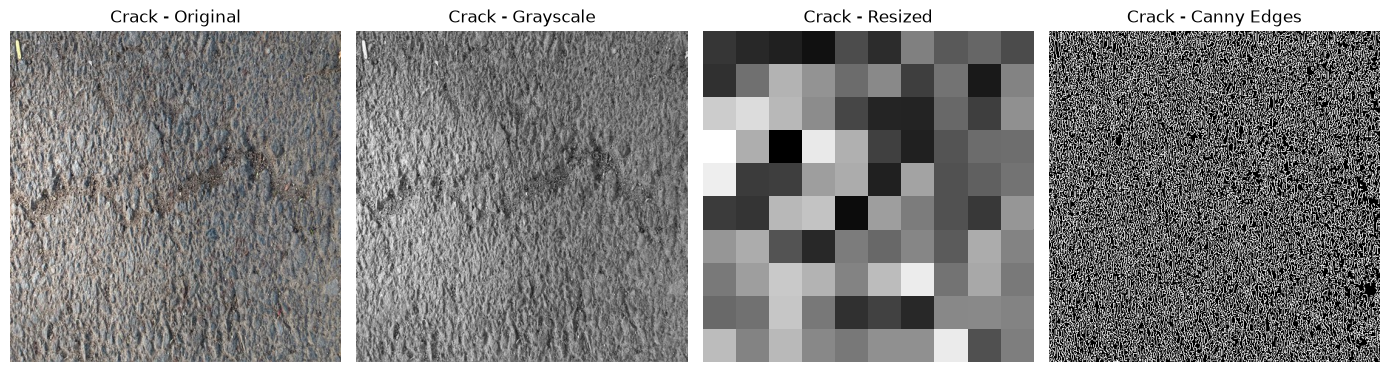

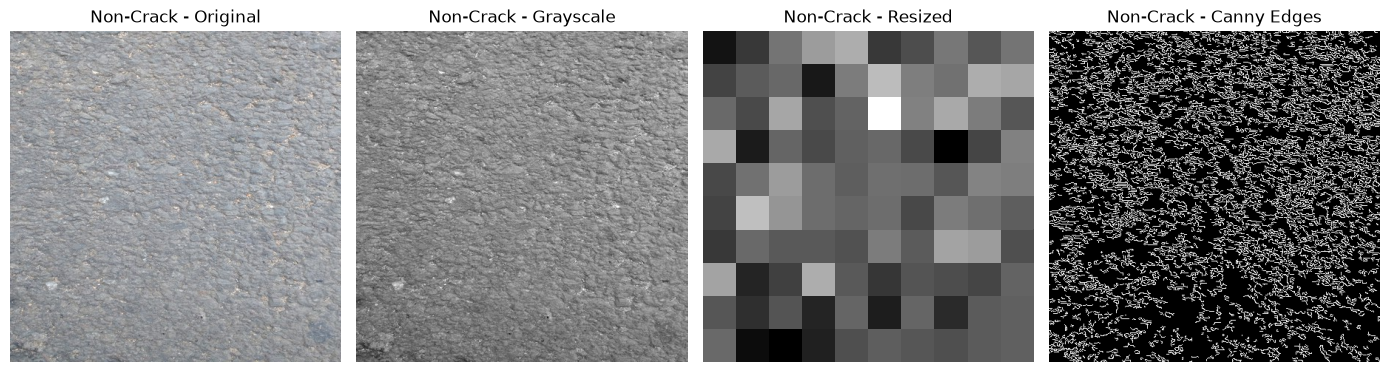

In [19]:
# ============================================================
# SAMPLE IMAGE VISUALIZATION
# ============================================================

def visualize_sample(folder):

    filename = os.listdir(folder)[0]
    image_path = os.path.join(folder, filename)

    image = cv2.imread(image_path)

    # Convert BGR to RGB for displaying the original image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize
    resized = cv2.resize(gray, (10, 10))

    # Canny Edge Detection
    edges = cv2.Canny(gray, 100, 200)

    return filename, image_rgb, gray, resized, edges


# Crack image
crack = visualize_sample("448/Cracks")

# Non-crack image
noncrack = visualize_sample("448/NonCracks")


# ------------------------------------------------------------
# Crack Visualization
# ------------------------------------------------------------

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(crack[1])
plt.title("Crack - Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(crack[2], cmap="gray")
plt.title("Crack - Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(crack[3], cmap="gray")
plt.title("Crack - Resized")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(crack[4], cmap="gray")
plt.title("Crack - Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Non-Crack Visualization
# ------------------------------------------------------------

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(noncrack[1])
plt.title("Non-Crack - Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(noncrack[2], cmap="gray")
plt.title("Non-Crack - Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(noncrack[3], cmap="gray")
plt.title("Non-Crack - Resized")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(noncrack[4], cmap="gray")
plt.title("Non-Crack - Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
feature_names = []

# 100 pixel features
for i in range(100):
    feature_names.append(f"pixel_{i}")

feature_names += [
    "mean_brightness",
    "contrast",
    "dark_ratio",
    "bright_ratio",
    "edge_count",
    "edge_density"
]

feature_df = pd.DataFrame(X, columns=feature_names)

feature_df["label"] = y
feature_df["image_name"] = image_names
feature_df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_98,pixel_99,mean_brightness,contrast,dark_ratio,bright_ratio,edge_count,edge_density,label,image_name
0,0.329412,0.294118,0.278431,0.239216,0.384314,0.305882,0.509804,0.415686,0.447059,0.380392,...,0.392157,0.505882,0.486549,0.142467,0.12,0.06,72585.0,0.361652,1,IMG_20180513_164959951_HDR resized_448.jpg
1,0.525490,0.482353,0.584314,0.529412,0.603922,0.537255,0.431373,0.419608,0.564706,0.411765,...,0.392157,0.470588,0.512588,0.093375,0.01,0.02,65773.0,0.327711,1,IMG_20180513_165129852_HDR resized_448.jpg
2,0.603922,0.431373,0.454902,0.478431,0.376471,0.298039,0.454902,0.466667,0.509804,0.431373,...,0.411765,0.552941,0.488471,0.137299,0.08,0.10,63187.0,0.314827,1,IMG_20180513_165150613_HDR resized_448.jpg
3,0.701961,0.556863,0.533333,0.282353,0.674510,0.654902,0.427451,0.415686,0.360784,0.380392,...,0.411765,0.772549,0.509333,0.112186,0.03,0.07,71668.0,0.357083,1,IMG_20180513_165345878_HDR resized_448.jpg
4,0.274510,0.466667,0.403922,0.650980,0.301961,0.482353,0.501961,0.482353,0.619608,0.666667,...,0.654902,0.611765,0.520000,0.098415,0.02,0.02,71719.0,0.357337,1,IMG_20180513_165349788_HDR resized_448.jpg


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(320, 106)
(80, 106)
(320,)
(80,)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
model = LogisticRegression(max_iter=1000)
start = time.perf_counter()
model.fit(X_train, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
y_pred = model.predict(X_test)
prediction_time = time.perf_counter() - start

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred))

print("\nTraining Time: ", train_time)
print("Predicting Time: ", prediction_time)

Accuracy:  0.675
Precision:  0.6842105263157895
Recall:  0.65
F1 Score:  0.6666666666666666
Confusion Matrix: 
[[28 12]
 [14 26]]

Training Time:  0.4013833999997587
Predicting Time:  0.0005364999997254927


In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.perf_counter()
rf_model.fit(X_train, y_train)
rf_train_time = time.perf_counter() - start

start = time.perf_counter()
rf_pred = rf_model.predict(X_test)
rf_prediction_time = time.perf_counter() - start

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("Training Time:", rf_train_time)
print("Prediction Time:", rf_prediction_time)


Random Forest
Accuracy: 0.9125
Precision: 0.9230769230769231
Recall: 0.9
F1: 0.9113924050632911
Confusion Matrix:
[[37  3]
 [ 4 36]]
Training Time: 0.38850729999830946
Prediction Time: 0.005893199999263743


In [9]:
image_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall
    ],
    "F1": [
        f1_score(y_test, y_pred),
        rf_f1
    ],
    "Training Time": [
        train_time,
        rf_train_time
    ],
    "Prediction Time": [
        prediction_time,
        rf_prediction_time
    ]
})

image_results

,Model,Accuracy,Precision,Recall,F1,Training Time,Prediction Time
0,Logistic Regression,0.6750,0.684211,0.65,0.666667,0.401383,0.000536
1,Random Forest,0.9125,0.923077,0.90,0.911392,0.388507,0.005893


## Part B


In [15]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load dataset
df = pd.read_csv("emails.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist()[:10])
print("...")
print(df.columns.tolist()[-10:])

# Remove Email No. because it is only an identifier
X = df.drop(columns=["Email No.", "Prediction"])

# Target
y = df["Prediction"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Dataset Shape: (5172, 3002)

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou']
...
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']

Feature Shape: (5172, 3000)
Target Shape: (5172,)

Target Distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Training Shape: (4137, 3000)
Testing Shape: (1035, 3000)


In [17]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training time
start_time = time.perf_counter()
model.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# Prediction time
start_time = time.perf_counter()
y_pred = model.predict(X_test)
prediction_time = time.perf_counter() - start_time

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("LOGISTIC REGRESSION")
print("Number of Features:", X.shape[1])
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Training Time:", train_time, "seconds")
print("Prediction Time:", prediction_time, "seconds")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.perf_counter()
rf_model.fit(
    X_train,
    y_train
)
rf_train_time = time.perf_counter() - start_time

print("Random Forest Training Completed")
print("Training Time:", rf_train_time, "seconds")

start_time = time.perf_counter()
rf_pred = rf_model.predict(
    X_test
)
rf_prediction_time = time.perf_counter() - start_time

print("Prediction Completed")
print("Prediction Time:", rf_prediction_time, "seconds")

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)
rf_precision = precision_score(
    y_test,
    rf_pred
)
rf_recall = recall_score(
    y_test,
    rf_pred
)
rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("\nRANDOM FOREST RESULTS")

print("Number of Features:", X_train.shape[1])
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("Training Time:", rf_train_time, "seconds")
print("Prediction Time:", rf_prediction_time, "seconds")

rf_cm = confusion_matrix(y_test,rf_pred)
print("\nConfusion Matrix:")
print(rf_cm)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

LOGISTIC REGRESSION
Number of Features: 3000
Accuracy: 0.9826086956521739
Precision: 0.9577922077922078
Recall: 0.9833333333333333
F1 Score: 0.9703947368421053
Training Time: 14.53234849999717 seconds
Prediction Time: 0.12169600000197534 seconds

Confusion Matrix:
[[722  13]
 [  5 295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       735
           1       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035

Random Forest Training Completed
Training Time: 2.3036535999999614 seconds
Prediction Completed
Prediction Time: 0.1429798999997729 seconds

RANDOM FOREST RESULTS
Number of Features: 3000
Accuracy: 0.9642512077294686
Precision: 0.933993399339934
Recall: 0.9433333333333334
F1 Score: 0.9386401326699834
Training Time: 2.3036535999999614 seconds
Prediction Time: 

In [ ]:
model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Number of Features": [
        X_train.shape[1],
        X_train.shape[1]
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        rf_precision
    ],

    "Recall": [
        recall,
        rf_recall
    ],

    "F1 Score": [
        f1,
        rf_f1
    ],

    "Training Time (sec)": [
        train_time,
        rf_train_time
    ],

    "Prediction Time (sec)": [
        prediction_time,
        rf_prediction_time
    ]
})

display(model_comparison)

,Model,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,Logistic Regression,3000,0.982609,0.957792,0.983333,0.970395,14.532348,0.121696
1,Random Forest,3000,0.964251,0.933993,0.943333,0.938640,2.303654,0.142980


Improved Feature Matrix Shape: (400, 106)
Improved Target Shape: (400,)
Class Distribution:
(array([0, 1]), array([200, 200]))

Training Data Shape: (320, 106)
Testing Data Shape: (80, 106)

 IMPROVED LOGISTIC REGRESSION
Number of Features: 106
Accuracy: 0.675
Precision: 0.6944444444444444
Recall: 0.625
F1 Score: 0.6578947368421053
Training Time: 0.25788679999823216 seconds
Prediction Time: 0.00192090000200551 seconds

Confusion Matrix:
[[29 11]
 [15 25]]

 IMPROVED RANDOM FOREST
Number of Features: 106
Accuracy: 0.9
Precision: 0.9
Recall: 0.9
F1 Score: 0.9
Training Time: 0.36288580000109505 seconds
Prediction Time: 0.041405600000871345 seconds

Confusion Matrix:
[[36  4]
 [ 4 36]]

 LOGISTIC REGRESSION: ORIGINAL VS IMPROVED


,Approach,Model,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,"Original Canny (100, 200)",Logistic Regression,3000,0.982609,0.957792,0.983333,0.970395,14.532348,0.121696
1,"Improved Canny (50, 150)",Logistic Regression,106,0.675000,0.694444,0.625000,0.657895,0.257887,0.001921



 RANDOM FOREST: ORIGINAL VS IMPROVED


,Approach,Model,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,"Original Canny (100, 200)",Random Forest,3000,0.964251,0.933993,0.943333,0.93864,2.303654,0.142980
1,"Improved Canny (50, 150)",Random Forest,106,0.900000,0.900000,0.900000,0.90000,0.362886,0.041406



              PART C — FINAL COMPARISON


,Approach,Model,Features,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,"Original Canny (100, 200)",Logistic Regression,3000,0.982609,0.957792,0.983333,0.970395,14.532348,0.121696
1,"Improved Canny (50, 150)",Logistic Regression,106,0.675000,0.694444,0.625000,0.657895,0.257887,0.001921
2,"Original Canny (100, 200)",Random Forest,3000,0.964251,0.933993,0.943333,0.938640,2.303654,0.142980
3,"Improved Canny (50, 150)",Random Forest,106,0.900000,0.900000,0.900000,0.900000,0.362886,0.041406


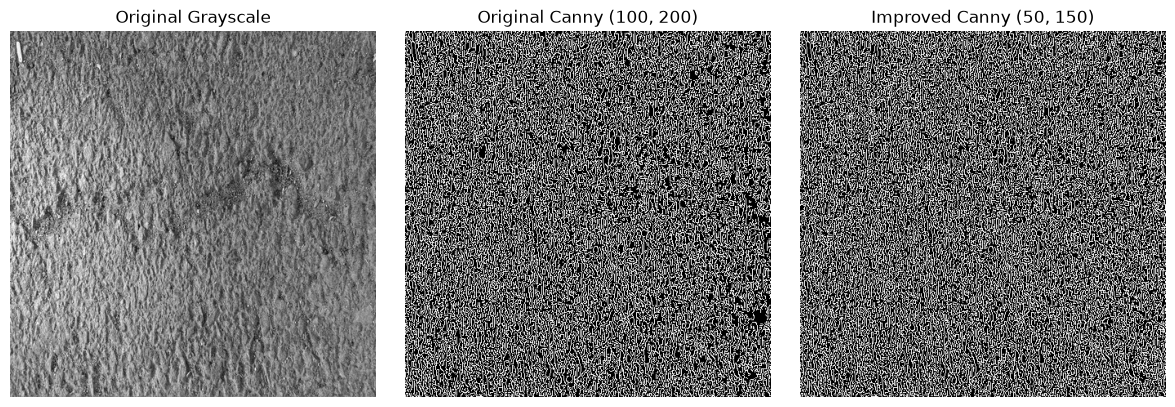


 CANNY EDGE FEATURE COMPARISON


,Canny Configuration,Edge Count,Edge Density
0,"Original (100, 200)",72585,0.361652
1,"Improved (50, 150)",75208,0.374721


In [ ]:
def extract_features_improved(image_path):

    # Read image
    image = cv2.imread(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    resized = cv2.resize(gray, (10, 10))

    # Normalize pixel values
    normalized = resized.astype(np.float32) / 255.0

    # Pixel Features
    pixel_features = normalized.flatten()

    # Intensity Features
    mean_brightness = np.mean(normalized)
    contrast = np.std(normalized)
    dark_ratio = np.mean(normalized < 0.3)
    bright_ratio = np.mean(normalized > 0.7)

    # IMPROVED CANNY EDGE DETECTION
    #
    # Original:
    # cv2.Canny(gray, 100, 200)
    #
    # Improved:
    # cv2.Canny(gray, 50, 150)

    edges = cv2.Canny(
        gray,
        50,
        150
    )

    # Edge features
    edge_count = np.sum(edges > 0)
    edge_density = np.mean(edges > 0)
    features = np.concatenate([
        pixel_features,
        [
            mean_brightness,
            contrast,
            dark_ratio,
            bright_ratio,
            edge_count,
            edge_density
        ]
    ])

    return features

X_improved = []
y_improved = []

crack_folder = "448/Cracks"

for filename in os.listdir(crack_folder):
    image_path = os.path.join(
        crack_folder,
        filename
    )
    features = extract_features_improved(image_path)
    X_improved.append(features)
    y_improved.append(1)

noncrack_folder = "448/NonCracks"

for filename in os.listdir(noncrack_folder):
    image_path = os.path.join(
        noncrack_folder,
        filename
    )
    features = extract_features_improved(image_path)
    X_improved.append(features)
    y_improved.append(0)


X_improved = np.array(X_improved)
y_improved = np.array(y_improved)

print("Improved Feature Matrix Shape:", X_improved.shape)
print("Improved Target Shape:", y_improved.shape)
print("Class Distribution:")
print(np.unique(y_improved, return_counts=True))

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(

    X_improved,
    y_improved,

    test_size=0.20,

    random_state=42,

    stratify=y_improved
)


print("\nTraining Data Shape:", X_train_imp.shape)

print("Testing Data Shape:", X_test_imp.shape)

lr_imp = LogisticRegression(
    max_iter=1000
)


# Training time
start_time = time.perf_counter()

lr_imp.fit(
    X_train_imp,
    y_train_imp
)

lr_imp_train_time = time.perf_counter() - start_time


# Prediction time
start_time = time.perf_counter()

lr_imp_pred = lr_imp.predict(
    X_test_imp
)

lr_imp_prediction_time = time.perf_counter() - start_time


# Evaluation
lr_imp_accuracy = accuracy_score(
    y_test_imp,
    lr_imp_pred
)

lr_imp_precision = precision_score(
    y_test_imp,
    lr_imp_pred
)

lr_imp_recall = recall_score(
    y_test_imp,
    lr_imp_pred
)

lr_imp_f1 = f1_score(
    y_test_imp,
    lr_imp_pred
)

lr_imp_cm = confusion_matrix(
    y_test_imp,
    lr_imp_pred
)

print(" IMPROVED LOGISTIC REGRESSION")
print("Number of Features:", X_train_imp.shape[1])
print("Accuracy:", lr_imp_accuracy)
print("Precision:", lr_imp_precision)
print("Recall:", lr_imp_recall)
print("F1 Score:", lr_imp_f1)
print("Training Time:", lr_imp_train_time, "seconds")
print("Prediction Time:", lr_imp_prediction_time, "seconds")
print("\nConfusion Matrix:")

print(lr_imp_cm)

rf_imp = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.perf_counter()

rf_imp.fit(
    X_train_imp,
    y_train_imp
)

rf_imp_train_time = time.perf_counter() - start_time

# Prediction time
start_time = time.perf_counter()

rf_imp_pred = rf_imp.predict(
    X_test_imp
)

rf_imp_prediction_time = time.perf_counter() - start_time


# Evaluation

rf_imp_accuracy = accuracy_score(
    y_test_imp,
    rf_imp_pred
)

rf_imp_precision = precision_score(
    y_test_imp,
    rf_imp_pred
)

rf_imp_recall = recall_score(
    y_test_imp,
    rf_imp_pred
)

rf_imp_f1 = f1_score(
    y_test_imp,
    rf_imp_pred
)

rf_imp_cm = confusion_matrix(
    y_test_imp,
    rf_imp_pred
)

print("\n==========================================")
print(" IMPROVED RANDOM FOREST")
print("==========================================")
print("Number of Features:", X_train_imp.shape[1])
print("Accuracy:", rf_imp_accuracy)
print("Precision:", rf_imp_precision)
print("Recall:", rf_imp_recall)
print("F1 Score:", rf_imp_f1)
print("Training Time:", rf_imp_train_time, "seconds")
print("Prediction Time:", rf_imp_prediction_time, "seconds")
print("\nConfusion Matrix:")
print(rf_imp_cm)

part_c_comparison = pd.DataFrame({
    "Approach": [
        "Original Canny (100, 200)",
        "Improved Canny (50, 150)"
    ],

    "Model": [
        "Logistic Regression",
        "Logistic Regression"
    ],

    "Number of Features": [
        X_train.shape[1],
        X_train_imp.shape[1]
    ],

    "Accuracy": [
        accuracy,
        lr_imp_accuracy
    ],

    "Precision": [
        precision,
        lr_imp_precision
    ],

    "Recall": [
        recall,
        lr_imp_recall
    ],

    "F1 Score": [
        f1,
        lr_imp_f1
    ],

    "Training Time (sec)": [
        train_time,
        lr_imp_train_time
    ],

    "Prediction Time (sec)": [
        prediction_time,
        lr_imp_prediction_time
    ]

})


print("\n==========================================")
print(" LOGISTIC REGRESSION: ORIGINAL VS IMPROVED")
print("==========================================")

display(part_c_comparison)


# ============================================================
# 7. RANDOM FOREST COMPARISON
# ============================================================

rf_comparison = pd.DataFrame({

    "Approach": [

        "Original Canny (100, 200)",

        "Improved Canny (50, 150)"

    ],

    "Model": [

        "Random Forest",

        "Random Forest"

    ],

    "Number of Features": [

        X_train.shape[1],

        X_train_imp.shape[1]

    ],

    "Accuracy": [

        rf_accuracy,

        rf_imp_accuracy

    ],

    "Precision": [

        rf_precision,

        rf_imp_precision

    ],

    "Recall": [

        rf_recall,

        rf_imp_recall

    ],

    "F1 Score": [

        rf_f1,

        rf_imp_f1

    ],

    "Training Time (sec)": [

        rf_train_time,

        rf_imp_train_time

    ],

    "Prediction Time (sec)": [

        rf_prediction_time,

        rf_imp_prediction_time

    ]

})


print("\n==========================================")
print(" RANDOM FOREST: ORIGINAL VS IMPROVED")
print("==========================================")

display(rf_comparison)

complete_part_c = pd.DataFrame({

    "Approach": [

        "Original Canny (100, 200)",

        "Improved Canny (50, 150)",

        "Original Canny (100, 200)",

        "Improved Canny (50, 150)"

    ],

    "Model": [

        "Logistic Regression",

        "Logistic Regression",

        "Random Forest",

        "Random Forest"

    ],

    "Features": [

        X_train.shape[1],

        X_train_imp.shape[1],

        X_train.shape[1],

        X_train_imp.shape[1]

    ],

    "Accuracy": [

        accuracy,

        lr_imp_accuracy,

        rf_accuracy,

        rf_imp_accuracy

    ],

    "Precision": [

        precision,

        lr_imp_precision,

        rf_precision,

        rf_imp_precision

    ],

    "Recall": [

        recall,

        lr_imp_recall,

        rf_recall,

        rf_imp_recall

    ],

    "F1 Score": [

        f1,

        lr_imp_f1,

        rf_f1,

        rf_imp_f1

    ],

    "Training Time (sec)": [

        train_time,

        lr_imp_train_time,

        rf_train_time,

        rf_imp_train_time

    ],

    "Prediction Time (sec)": [

        prediction_time,

        lr_imp_prediction_time,

        rf_prediction_time,

        rf_imp_prediction_time

    ]

})
print("\nPART C — FINAL COMPARISON")

display(complete_part_c)

sample_filename = os.listdir("448/Cracks")[0]

sample_path = os.path.join(
    "448/Cracks",
    sample_filename
)

sample_image = cv2.imread(sample_path)

sample_gray = cv2.cvtColor(
    sample_image,
    cv2.COLOR_BGR2GRAY
)


# Original Canny
original_edges = cv2.Canny(
    sample_gray,
    100,
    200
)


# Improved Canny
improved_edges = cv2.Canny(
    sample_gray,
    50,
    150
)


plt.figure(figsize=(12, 4))


plt.subplot(1, 3, 1)

plt.imshow(
    sample_gray,
    cmap="gray"
)

plt.title("Original Grayscale")

plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    original_edges,
    cmap="gray"
)
plt.title("Original Canny (100, 200)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    improved_edges,
    cmap="gray"
)
plt.title("Improved Canny (50, 150)")
plt.axis("off")
plt.tight_layout()
plt.show()

original_edge_count = np.sum(
    original_edges > 0
)

improved_edge_count = np.sum(
    improved_edges > 0
)

original_edge_density = np.mean(
    original_edges > 0
)

improved_edge_density = np.mean(
    improved_edges > 0
)

edge_comparison = pd.DataFrame({
    "Canny Configuration": [
        "Original (100, 200)",
        "Improved (50, 150)"
    ],

    "Edge Count": [
        original_edge_count,
        improved_edge_count

    ],

    "Edge Density": [

        original_edge_density,

        improved_edge_density

    ]

})
print(" CANNY EDGE FEATURE COMPARISON")
display(edge_comparison)